In [1]:
from google.colab import files

uploaded = files.upload()  # This will prompt you to upload your events.csv


Saving archive.zip to archive.zip


In [2]:
uploaded.keys()

dict_keys(['archive.zip'])

In [13]:
"""
Extract and Explore Kaggle LinkedIn Dataset
"""

import pandas as pd
import zipfile
import os

# ============================================================================
# 1. EXTRACT THE ZIP FILE
# ============================================================================

print("Extracting archive.zip...")
with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('linkedin_data')
print("✓ Extraction complete!\n")

# ============================================================================
# 2. LIST ALL EXTRACTED FILES
# ============================================================================

print("=" * 70)
print("FILES IN THE DATASET")
print("=" * 70)

csv_files = []
for root, dirs, files in os.walk('linkedin_data'):
    for file in files:
        if file.endswith('.csv'):
            filepath = os.path.join(root, file)
            csv_files.append(filepath)
            size_mb = os.path.getsize(filepath) / (1024 * 1024)
            print(f"\n📄 {file}")
            print(f"   Size: {size_mb:.2f} MB")

print(f"\n✓ Found {len(csv_files)} CSV files\n")

# ============================================================================
# 3. LOAD THE MAIN FILE (job_postings.csv)
# ============================================================================

print("=" * 70)
print("LOADING MAIN FILE: job_postings.csv")
print("=" * 70)

# Find the job_postings file
job_postings_file = [f for f in csv_files if 'posting' in f.lower()][0]
print(f"\nLoading: {job_postings_file}")

# Load first 5000 rows for exploration
df = pd.read_csv(job_postings_file, nrows=5000)
print(f"✓ Loaded {len(df):,} rows × {len(df.columns)} columns\n")

# ============================================================================
# 4. SHOW COLUMN NAMES
# ============================================================================

print("=" * 70)
print("COLUMN NAMES")
print("=" * 70)
print(f"\nTotal: {len(df.columns)} columns\n")

for i, col in enumerate(df.columns, 1):
    print(f"{i:3d}. {col}")

# ============================================================================
# 5. SHOW FIRST 3 ROWS
# ============================================================================

print("\n" + "=" * 70)
print("FIRST 3 ROWS (Sample Data)")
print("=" * 70)
print(df.head(3))

# ============================================================================
# 6. DATA TYPES
# ============================================================================

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)
print(df.dtypes)

# ============================================================================
# 7. MISSING VALUES
# ============================================================================

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing': missing,
    'Percentage': missing_pct
}).sort_values('Missing', ascending=False)

print("\nTop 15 columns with most missing values:")
print(missing_df.head(15).to_string(index=False))

# ============================================================================
# 8. KEY INSIGHTS
# ============================================================================

print("\n" + "=" * 70)
print("KEY INSIGHTS")
print("=" * 70)

# Look for title column
title_cols = [col for col in df.columns if 'title' in col.lower()]
if title_cols:
    print(f"\n📊 Top 10 Job Titles (from '{title_cols[0]}'):")
    print(df[title_cols[0]].value_counts().head(10))

# Look for location
location_cols = [col for col in df.columns if 'location' in col.lower() or 'city' in col.lower()]
if location_cols:
    print(f"\n📍 Top 10 Locations (from '{location_cols[0]}'):")
    print(df[location_cols[0]].value_counts().head(10))

# Look for date
date_cols = [col for col in df.columns if 'date' in col.lower() or 'posted' in col.lower()]
if date_cols:
    print(f"\n📅 Date Column: '{date_cols[0]}'")
    print(f"   Sample values: {df[date_cols[0]].dropna().head(3).tolist()}")

# ============================================================================
# 9. SUMMARY
# ============================================================================

print("\n" + "=" * 70)
print("SUMMARY - READY TO BUILD PROJECT")
print("=" * 70)

print("""
✓ Data loaded successfully!

Now I need you to copy-paste:
1. The COLUMN NAMES list above
2. The FIRST 3 ROWS output

Then I'll create:
✓ Complete trending jobs prediction code
✓ Professional README.md
✓ GitHub-ready project
""")

print("\n📋 QUICK REFERENCE - Column Names:")
print(df.columns.tolist())

Extracting archive.zip...
✓ Extraction complete!

FILES IN THE DATASET

📄 postings.csv
   Size: 492.90 MB

📄 companies.csv
   Size: 22.12 MB

📄 company_specialities.csv
   Size: 4.23 MB

📄 company_industries.csv
   Size: 0.75 MB

📄 employee_counts.csv
   Size: 1.00 MB

📄 job_skills.csv
   Size: 3.34 MB

📄 salaries.csv
   Size: 2.15 MB

📄 benefits.csv
   Size: 1.84 MB

📄 job_industries.csv
   Size: 2.39 MB

📄 skills.csv
   Size: 0.00 MB

📄 industries.csv
   Size: 0.01 MB

✓ Found 11 CSV files

LOADING MAIN FILE: job_postings.csv

Loading: linkedin_data/postings.csv
✓ Loaded 5,000 rows × 31 columns

COLUMN NAMES

Total: 31 columns

  1. job_id
  2. company_name
  3. title
  4. description
  5. max_salary
  6. pay_period
  7. location
  8. company_id
  9. views
 10. med_salary
 11. min_salary
 12. formatted_work_type
 13. applies
 14. original_listed_time
 15. remote_allowed
 16. job_posting_url
 17. application_url
 18. application_type
 19. expiry
 20. closed_time
 21. formatted_experie

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             classification_report)

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("LINKEDIN JOB POSTINGS ANALYSIS - TRENDING JOBS 2026")
print("\n✓ Libraries imported successfully\n")

df = pd.read_csv('linkedin_data/postings.csv', nrows=50000)

print(f"✓ Dataset loaded: {len(df):,} rows × {len(df.columns)} columns")
print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")

LINKEDIN JOB POSTINGS ANALYSIS - TRENDING JOBS 2026

✓ Libraries imported successfully

✓ Dataset loaded: 50,000 rows × 31 columns
  Memory usage: 363.31 MB



EXPLORATORY DATA ANALYSIS

1. Dataset Overview:
   • Total job postings: 50,000
   • Number of features: 31
   • Date range: 2024-04-05 19:34:32 to 2024-04-20 00:14:00

2. Column Types:
   • Numerical: 16
   • Categorical: 15

3. Missing Values (Top 10):
                   Missing Count  Percentage
closed_time                49172       98.34
skills_desc                49059       98.12
med_salary                 47350       94.70
remote_allowed             43662       87.32
applies                    38572       77.14
min_salary                 38075       76.15
max_salary                 38075       76.15
currency                   35425       70.85
compensation_type          35425       70.85
pay_period                 35425       70.85

4. Key Statistics:
   • Unique job titles: 31,046
   • Unique companies: 13,354
   • Unique locations: 5,713
   • Average views per job: 17.4
   • Average applications: 11.2

5. Top 15 Most Common Job Titles:
title
Sales Manager                     

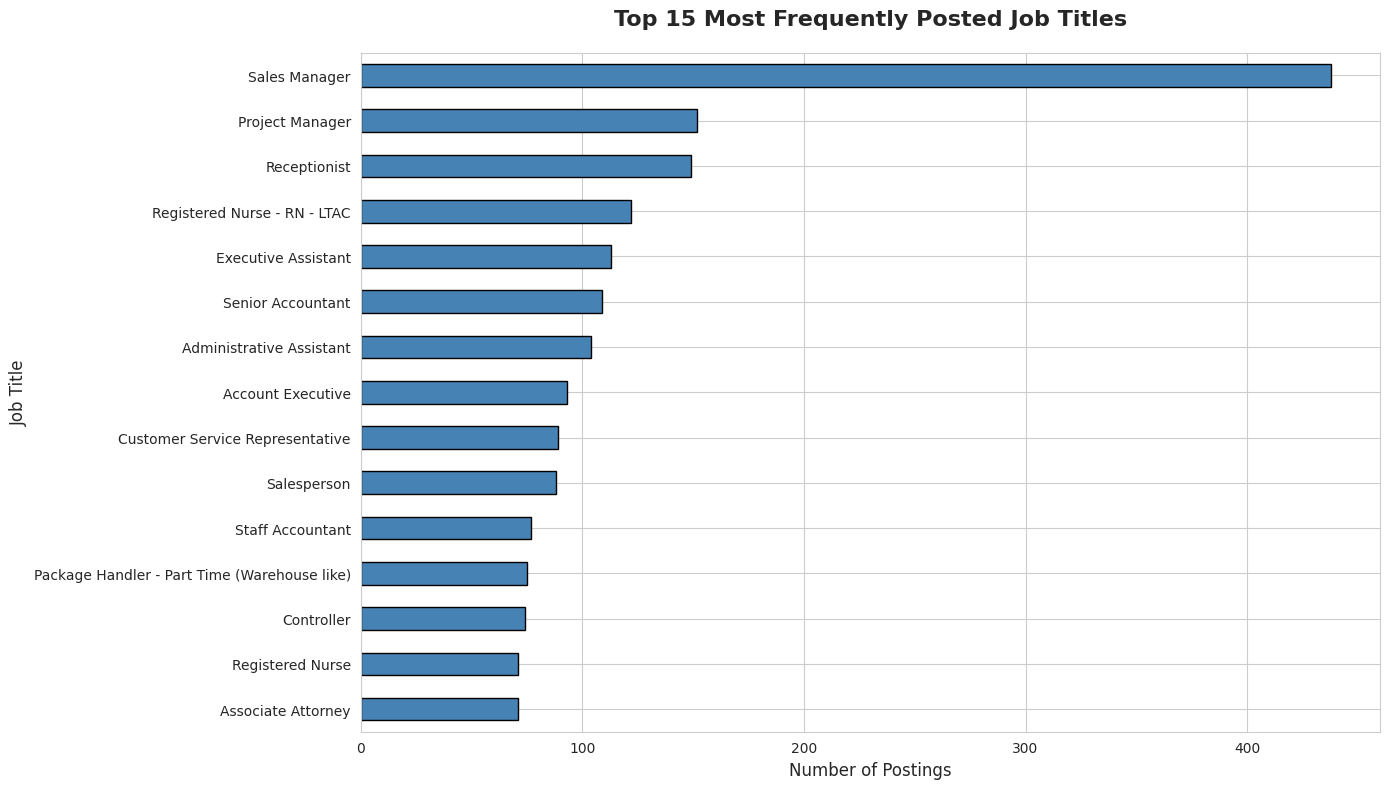


6. Top 10 Job Locations:
location
United States      3336
New York, NY       1057
Houston, TX         787
Chicago, IL         730
Dallas, TX          556
Atlanta, GA         515
Los Angeles, CA     436
Boston, MA          432
Charlotte, NC       423
Phoenix, AZ         418
Name: count, dtype: int64


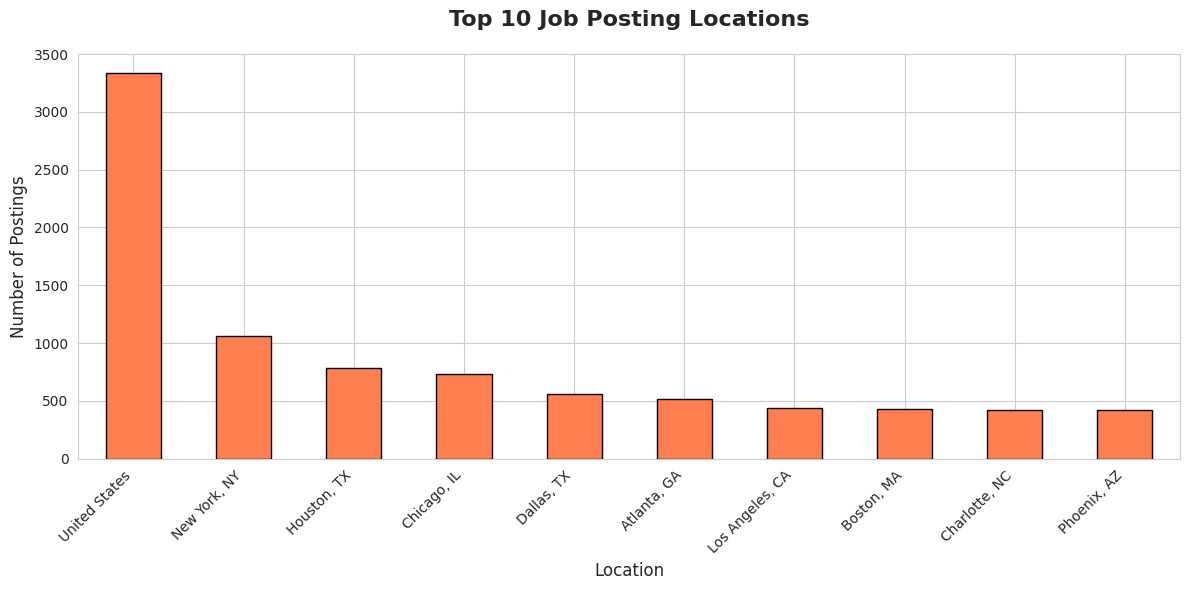

In [16]:
#exploratory data analysis
def perform_eda(data):
    """
    Comprehensive exploratory data analysis
    """
    print("=" * 80)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 80)

    # Basic information
    print(f"\n1. Dataset Overview:")
    print(f"   • Total job postings: {len(data):,}")
    print(f"   • Number of features: {len(data.columns)}")
    print(f"   • Date range: {pd.to_datetime(data['listed_time'], unit='ms').min()} to {pd.to_datetime(data['listed_time'], unit='ms').max()}")

    # Column information
    print(f"\n2. Column Types:")
    print(f"   • Numerical: {len(data.select_dtypes(include=['int64', 'float64']).columns)}")
    print(f"   • Categorical: {len(data.select_dtypes(include=['object']).columns)}")

    # Missing values
    print(f"\n3. Missing Values (Top 10):")
    missing = data.isnull().sum()
    missing_pct = (missing / len(data) * 100).round(2)
    missing_df = pd.DataFrame({
        'Missing Count': missing,
        'Percentage': missing_pct
    }).sort_values('Missing Count', ascending=False)
    print(missing_df[missing_df['Missing Count'] > 0].head(10))

    # Key statistics
    print(f"\n4. Key Statistics:")
    print(f"   • Unique job titles: {data['title'].nunique():,}")
    print(f"   • Unique companies: {data['company_name'].dropna().nunique():,}")
    print(f"   • Unique locations: {data['location'].dropna().nunique():,}")
    print(f"   • Average views per job: {data['views'].mean():.1f}")
    print(f"   • Average applications: {data['applies'].mean():.1f}")

    return missing_df

# Perform EDA
missing_analysis = perform_eda(df)

# Visualize top job titles
print("\n5. Top 15 Most Common Job Titles:")
top_titles = df['title'].value_counts().head(15)
print(top_titles)

plt.figure(figsize=(14, 8))
top_titles.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Most Frequently Posted Job Titles', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Postings', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Visualize top locations
print("\n6. Top 10 Job Locations:")
top_locations = df['location'].value_counts().head(10)
print(top_locations)

plt.figure(figsize=(12, 6))
top_locations.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Top 10 Job Posting Locations', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Number of Postings', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
#data cleaning
def clean_data(data):
    """
    Clean and preprocess the dataset
    """
    print("DATA CLEANING & PREPROCESSING")
    df_clean = data.copy()
    initial_rows = len(df_clean)

    # 1. Handle critical missing values
    print(f"   • Removing rows without job title: {df_clean['title'].isnull().sum()}")
    df_clean = df_clean.dropna(subset=['title'])

    print(f"   • Removing rows without listing time: {df_clean['listed_time'].isnull().sum()}")
    df_clean = df_clean.dropna(subset=['listed_time'])

    # 2. Clean job titles
    df_clean['title'] = df_clean['title'].str.strip().str.lower()
    df_clean['title'] = df_clean['title'].str.replace(r'\s+', ' ', regex=True)

    # 3. Convert timestamps to datetime
    df_clean['posted_date'] = pd.to_datetime(df_clean['listed_time'], unit='ms')
    df_clean['year'] = df_clean['posted_date'].dt.year
    df_clean['month'] = df_clean['posted_date'].dt.month
    df_clean['quarter'] = df_clean['posted_date'].dt.quarter

    # 4. Handle location data
    df_clean['location'] = df_clean['location'].fillna('Unknown')
    df_clean['is_remote'] = df_clean['remote_allowed'].fillna(0).astype(int)

    # 5. Remove duplicates
    before_dup = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=['title', 'company_name', 'location', 'listed_time'])
    removed_dup = before_dup - len(df_clean)
    print(f"   • Removed {removed_dup:,} duplicate postings")

    final_rows = len(df_clean)
    print(f"\n✓ Cleaning complete:")
    print(f"  • Initial rows: {initial_rows:,}")
    print(f"  • Final rows: {final_rows:,}")
    print(f"  • Rows removed: {initial_rows - final_rows:,} ({(initial_rows - final_rows) / initial_rows * 100:.2f}%)")

    return df_clean

# Clean the data
df_clean = clean_data(df)


DATA CLEANING & PREPROCESSING
   • Removing rows without job title: 0
   • Removing rows without listing time: 0
   • Removed 952 duplicate postings

✓ Cleaning complete:
  • Initial rows: 50,000
  • Final rows: 49,048
  • Rows removed: 952 (1.90%)


FEATURE ENGINEERING

   • Median job frequency: 1 postings
   • Trending jobs: 23,125 (47.1%)
   • Non-trending jobs: 25,923 (52.9%)

9. Job Category Distribution:
job_category
Other                   19614
Management              12176
Healthcare               4084
Engineering              3124
Sales & Marketing        2816
Finance                  2587
Software Development     1744
Customer Service          954
Design                    786
Data Science & AI         659
Human Resources           504
Name: count, dtype: int64


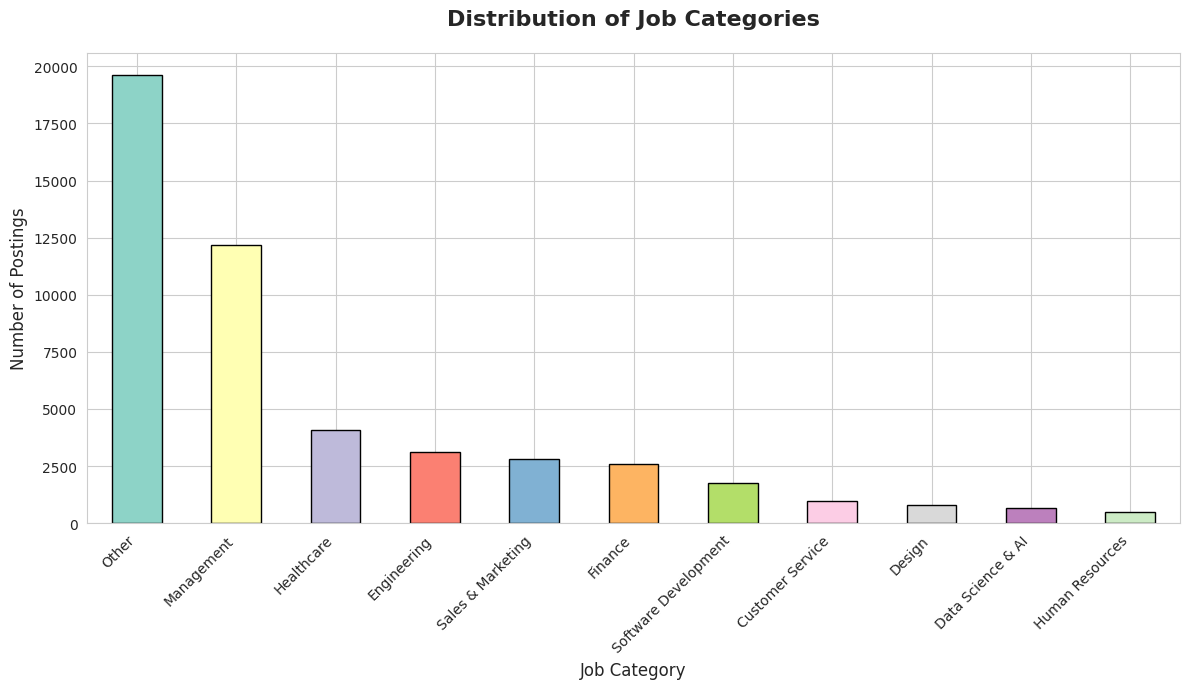

In [19]:
#feature engineering
def extract_job_category(title):
    """
    Categorize job titles into broad categories
    """
    title = str(title).lower()

    categories = {
        'Data Science & AI': ['data scientist', 'machine learning', 'ai engineer', 'data analyst',
                              'business intelligence', 'analytics', 'data engineer'],
        'Software Development': ['software engineer', 'developer', 'programmer', 'frontend',
                                'backend', 'full stack', 'devops'],
        'Management': ['manager', 'director', 'head', 'lead', 'chief', 'executive', 'supervisor'],
        'Sales & Marketing': ['sales', 'marketing', 'business development', 'account manager',
                             'sales rep'],
        'Healthcare': ['nurse', 'therapist', 'medical', 'healthcare', 'physician', 'doctor',
                       'clinical'],
        'Engineering': ['engineer', 'mechanical', 'civil', 'electrical', 'project engineer'],
        'Customer Service': ['customer service', 'support', 'customer success', 'client service'],
        'Finance': ['accountant', 'financial', 'finance', 'analyst', 'auditor'],
        'Human Resources': ['hr', 'human resources', 'recruiter', 'talent acquisition'],
        'Design': ['designer', 'ux', 'ui', 'graphic design', 'creative'],
    }

    for category, keywords in categories.items():
        if any(keyword in title for keyword in keywords):
            return category

    return 'Other'


def create_features(data):
    """
    Engineer features for machine learning
    """
    print("FEATURE ENGINEERING")

    df_features = data.copy()

    # 1. Job category
    df_features['job_category'] = df_features['title'].apply(extract_job_category)

    # 2. Experience level (clean and simplify)
    df_features['experience_level'] = df_features['formatted_experience_level'].fillna('Not Specified')

    # 3. Work type
    df_features['work_type_clean'] = df_features['work_type'].fillna('Not Specified')

    # 4. Has salary info
    df_features['has_salary'] = (~df_features['normalized_salary'].isnull()).astype(int)
    df_features['salary_range'] = df_features['max_salary'] - df_features['min_salary']
    df_features['salary_range'] = df_features['salary_range'].fillna(0)

    # 5. Application metrics
    df_features['view_to_apply_ratio'] = df_features['applies'] / (df_features['views'] + 1)
    df_features['view_to_apply_ratio'] = df_features['view_to_apply_ratio'].fillna(0)
    df_features['high_engagement'] = (df_features['view_to_apply_ratio'] > df_features['view_to_apply_ratio'].median()).astype(int)

    # 6. Calculate trend score (how often this job title appears)
    job_counts = df_features.groupby('title').size()
    df_features['job_frequency'] = df_features['title'].map(job_counts)

    # 7. Yearly job growth
    yearly_counts = df_features.groupby(['title', 'year']).size().reset_index(name='yearly_count')
    df_features = df_features.merge(yearly_counts, on=['title', 'year'], how='left')

    # 8. Create target variable: Is this job trending?
    # A job is "trending" if it appears more frequently than the median
    median_frequency = df_features['job_frequency'].median()
    df_features['is_trending'] = (df_features['job_frequency'] > median_frequency).astype(int)

    print(f"\n   • Median job frequency: {median_frequency:.0f} postings")
    print(f"   • Trending jobs: {df_features['is_trending'].sum():,} ({df_features['is_trending'].mean()*100:.1f}%)")
    print(f"   • Non-trending jobs: {(~df_features['is_trending'].astype(bool)).sum():,} ({(1-df_features['is_trending'].mean())*100:.1f}%)")

    # 9. Show job category distribution
    print("\n9. Job Category Distribution:")
    category_dist = df_features['job_category'].value_counts()
    print(category_dist)

    return df_features

# Create features
df_features = create_features(df_clean)

# Visualize job categories
plt.figure(figsize=(12, 7))
category_counts = df_features['job_category'].value_counts()
colors = plt.cm.Set3(range(len(category_counts)))
category_counts.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Distribution of Job Categories', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Job Category', fontsize=12)
plt.ylabel('Number of Postings', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [20]:
#prepare data for modeling
def prepare_modeling_data(data):
    """
    Prepare data for machine learning
    """
    print("PREPARING DATA FOR MODELING")

    df_model = data.copy()

    # Select features for modeling
    # NOTE: We exclude job_frequency and yearly_count to avoid data leakage
    feature_columns = [
        'title', 'company_name', 'location', 'work_type_clean',
        'experience_level', 'job_category', 'is_remote',
        'has_salary', 'year', 'month', 'quarter'
    ]

    target_column = 'is_trending'

    # Handle missing values in features
    for col in feature_columns:
        if df_model[col].dtype == 'object':
            df_model[col] = df_model[col].fillna('Unknown')

    # Label encoding for categorical variables
    label_encoders = {}
    categorical_cols = [col for col in feature_columns if df_model[col].dtype == 'object']

    for col in categorical_cols:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        label_encoders[col] = le
        print(f"   • Encoded {col}: {len(le.classes_):,} unique values")

    # Prepare X and y
    X = df_model[feature_columns]
    y = df_model[target_column]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"   • Training set: {len(X_train):,} samples")
    print(f"   • Test set: {len(X_test):,} samples")
    print(f"   • Class distribution in train: {y_train.value_counts().to_dict()}")

    print("\n✓ Data preparation complete")

    return X_train, X_test, y_train, y_test, label_encoders, feature_columns

# Prepare data
X_train, X_test, y_train, y_test, label_encoders, feature_columns = prepare_modeling_data(df_features)


PREPARING DATA FOR MODELING
   • Encoded title: 30,741 unique values
   • Encoded company_name: 13,355 unique values
   • Encoded location: 5,713 unique values
   • Encoded work_type_clean: 7 unique values
   • Encoded experience_level: 7 unique values
   • Encoded job_category: 11 unique values
   • Training set: 39,238 samples
   • Test set: 9,810 samples
   • Class distribution in train: {0: 20738, 1: 18500}

✓ Data preparation complete


In [22]:
#model training
def train_and_compare_models(X_train, X_test, y_train, y_test):
    """
    Train multiple models and compare performance
    """
    print("MODEL TRAINING & COMPARISON")

    # Define models
    models = {
        'Random Forest': RandomForestClassifier(
            n_estimators=100,
            max_depth=20,
            min_samples_split=10,
            random_state=42,
            n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=42
        ),
        'Logistic Regression': LogisticRegression(
            max_iter=1000,
            random_state=42,
            n_jobs=-1
        )
    }

    results = {}

    for name, model in models.items():
        print(f"Training: {name}")

        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        # Store results
        results[name] = {
            'model': model,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }

        # Print metrics
        print(f"\n   Results:")
        print(f"   • Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
        print(f"   • Precision: {precision:.4f}")
        print(f"   • Recall:    {recall:.4f}")
        print(f"   • F1-Score:  {f1:.4f}")

    # Find best model
    best_model_name = max(results, key=lambda x: results[x]['f1_score'])

    print(f"🏆 BEST MODEL: {best_model_name}")
    print(f"   F1-Score: {results[best_model_name]['f1_score']:.4f}")

    return results, best_model_name

# Train models
model_results, best_model_name = train_and_compare_models(X_train, X_test, y_train, y_test)


MODEL TRAINING & COMPARISON
Training: Random Forest

   Results:
   • Accuracy:  0.7016 (70.16%)
   • Precision: 0.7477
   • Recall:    0.5542
   • F1-Score:  0.6365
Training: Gradient Boosting

   Results:
   • Accuracy:  0.6787 (67.87%)
   • Precision: 0.7271
   • Recall:    0.5098
   • F1-Score:  0.5994
Training: Logistic Regression

   Results:
   • Accuracy:  0.5318 (53.18%)
   • Precision: 0.5077
   • Recall:    0.2277
   • F1-Score:  0.3144
🏆 BEST MODEL: Random Forest
   F1-Score: 0.6365


DETAILED EVALUATION: Random Forest

1. Classification Report:
              precision    recall  f1-score   support

Not Trending       0.68      0.83      0.75      5185
    Trending       0.75      0.55      0.64      4625

    accuracy                           0.70      9810
   macro avg       0.71      0.69      0.69      9810
weighted avg       0.71      0.70      0.69      9810



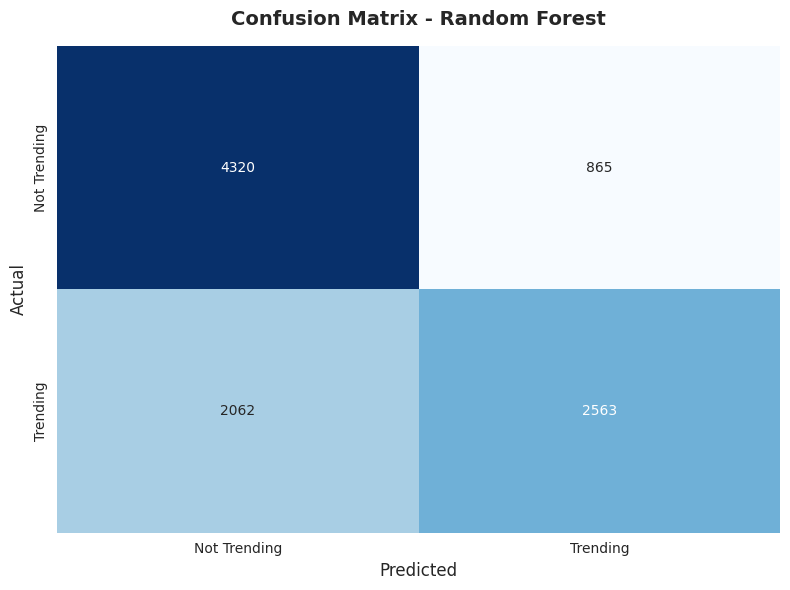

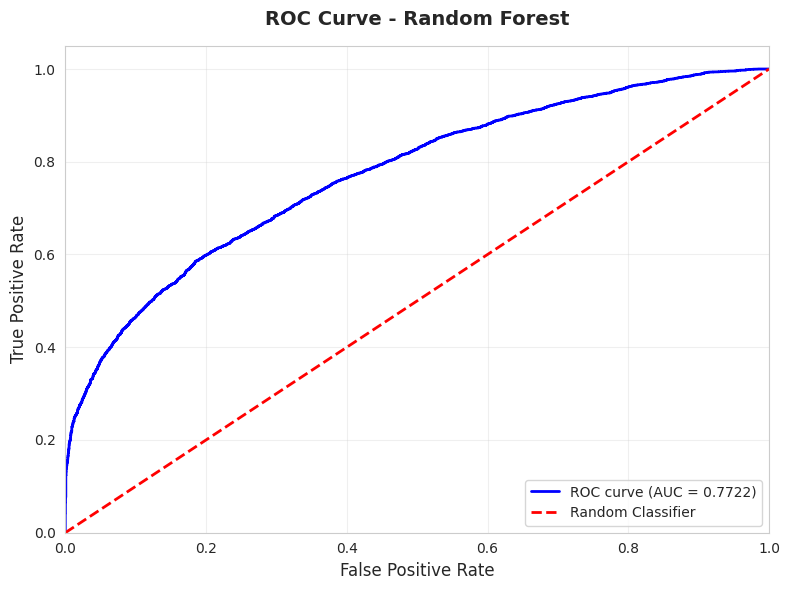


2. Feature Importance Analysis:

Top 10 Most Important Features:
         Feature  Importance
           title    0.303902
    company_name    0.301988
        location    0.176322
    job_category    0.083632
experience_level    0.055572
 work_type_clean    0.045792
       is_remote    0.016812
      has_salary    0.015981
            year    0.000000
           month    0.000000


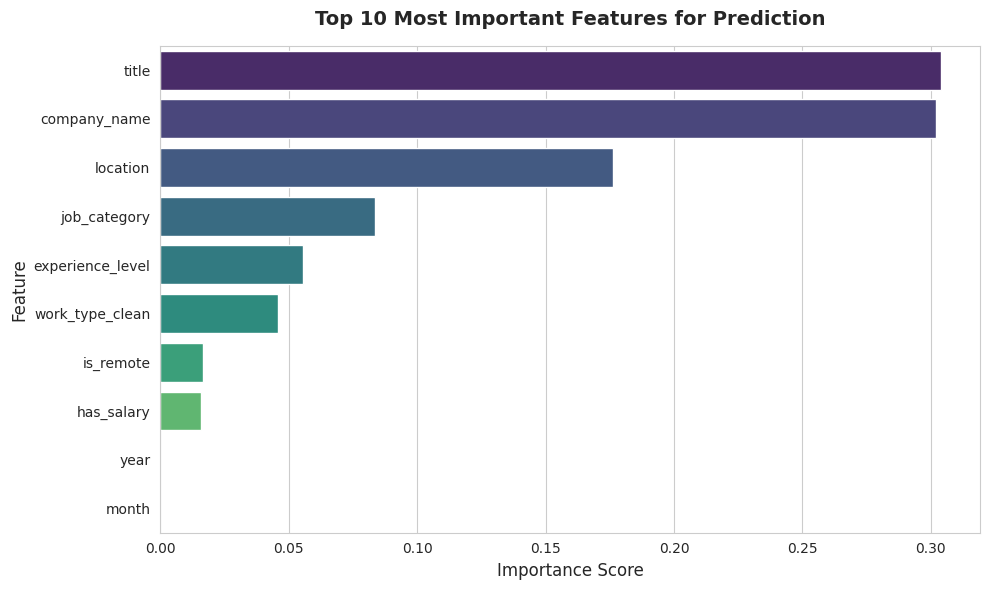

In [23]:
#model evaluation
print(f"DETAILED EVALUATION: {best_model_name}")

best_model = model_results[best_model_name]['model']
y_pred = model_results[best_model_name]['predictions']
y_pred_proba = model_results[best_model_name]['probabilities']

# Classification report
print("\n1. Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Trending', 'Trending']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Trending', 'Trending'],
            yticklabels=['Not Trending', 'Trending'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve - {best_model_name}', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Feature importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    print("\n2. Feature Importance Analysis:")
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))

    plt.figure(figsize=(10, 6))
    top_features = feature_importance.head(10)
    sns.barplot(data=top_features, y='Feature', x='Importance', palette='viridis')
    plt.title('Top 10 Most Important Features for Prediction', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()


PREDICTING TRENDING JOBS FOR 2026

Analyzing 1,000 unique job titles...
Making predictions...

✓ Predictions complete!

TOP 20 TRENDING JOBS PREDICTED FOR 2026
                                     Job Title  Trending Probability
                             Account Executive              0.598532
                   Customer Service Specialist              0.575898
                                  Data Analyst              0.571398
          Cybersecurity Test Engineer – Remote              0.571398
                                Data Architect              0.571398
                Account Executive - Mid-Market              0.568532
                               Account Manager              0.567532
                     Customer Advocacy Manager              0.565898
   Cyber Security /Report Developer ( W2 Role)              0.565898
                      Customer Success Manager              0.565898
                        Customer Service Agent              0.565898
Customer Se

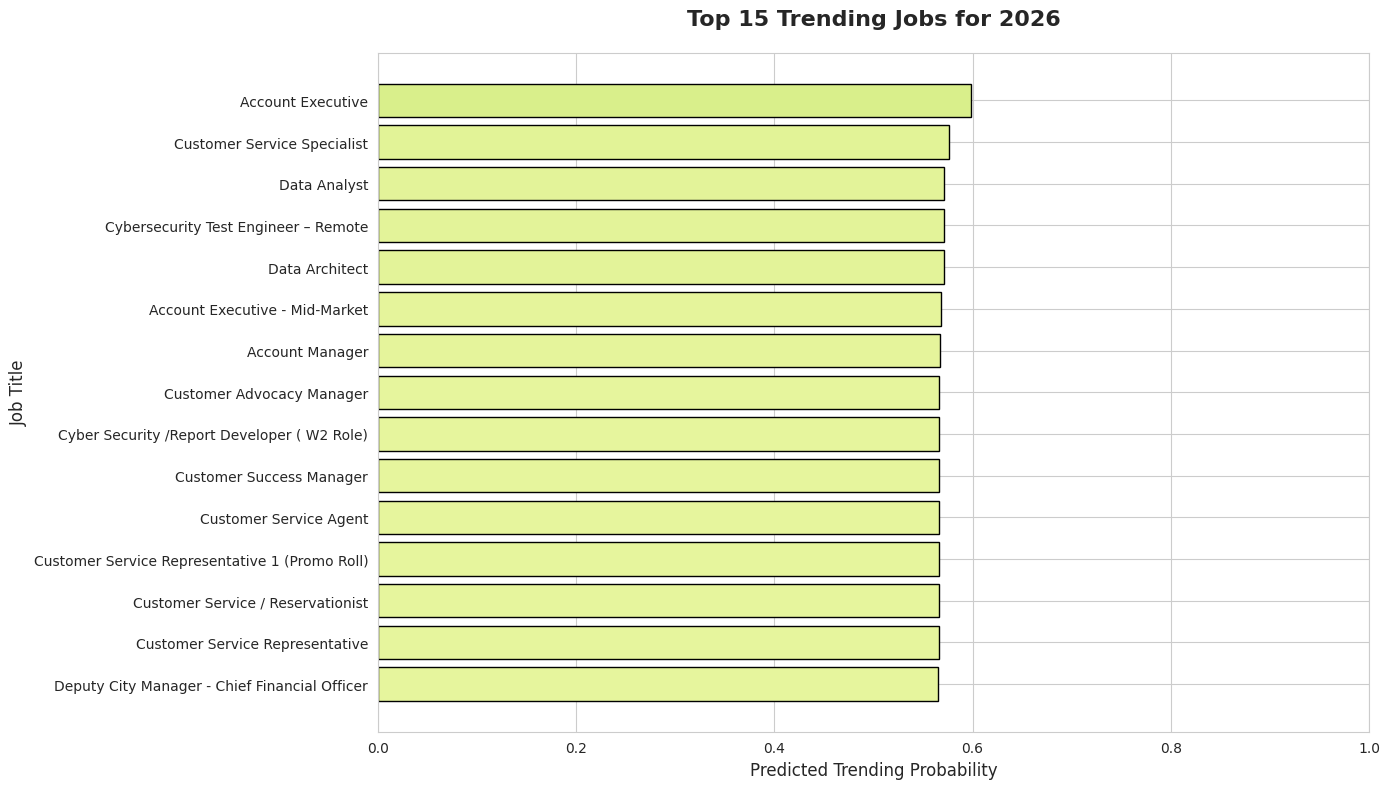

In [24]:
#predicting 2026 trending job
def predict_2026_trends(model, X_train, df_original, label_encoders):
    """
    Predict trending jobs for 2026
    """
    print("\n" + "=" * 80)
    print("PREDICTING TRENDING JOBS FOR 2026")
    print("=" * 80)

    # Get unique job titles
    unique_jobs = df_original['title'].dropna().unique()[:1000]  # Limit to top 1000 for speed

    print(f"\nAnalyzing {len(unique_jobs):,} unique job titles...")

    # Create 2026 prediction data
    future_data = []

    for job_title in unique_jobs:
        row = {
            'title': job_title,
            'year': 2026,
            'month': 6,  # Mid-year
            'quarter': 2
        }

        # Fill other features with mode from training data
        for col in X_train.columns:
            if col not in row:
                row[col] = X_train[col].mode()[0]

        future_data.append(row)

    future_df = pd.DataFrame(future_data)

    # Encode categorical features
    for col in label_encoders.keys():
        if col in future_df.columns:
            # Handle unseen labels
            le = label_encoders[col]
            future_df[col] = future_df[col].apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )

    # Make predictions
    print("Making predictions...")
    X_future = future_df[X_train.columns]
    trending_proba = model.predict_proba(X_future)[:, 1]

    # Create results
    predictions_2026 = pd.DataFrame({
        'Job Title': [str(title).title() for title in unique_jobs],
        'Trending Probability': trending_proba
    }).sort_values('Trending Probability', ascending=False)

    print("\n✓ Predictions complete!")

    return predictions_2026

# Make predictions
predictions_2026 = predict_2026_trends(best_model, X_train, df_clean, label_encoders)

# Display results
print("\n" + "=" * 80)
print("TOP 20 TRENDING JOBS PREDICTED FOR 2026")
print("=" * 80)
print(predictions_2026.head(20).to_string(index=False))

# Visualize top 15
plt.figure(figsize=(14, 8))
top_15 = predictions_2026.head(15)
colors = plt.cm.RdYlGn(top_15['Trending Probability'])
plt.barh(range(len(top_15)), top_15['Trending Probability'], color=colors, edgecolor='black')
plt.yticks(range(len(top_15)), top_15['Job Title'])
plt.xlabel('Predicted Trending Probability', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.title('Top 15 Trending Jobs for 2026', fontsize=16, fontweight='bold', pad=20)
plt.xlim(0, 1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [25]:
#insight recommendation
print("\n" + "=" * 80)
print("KEY INSIGHTS & RECOMMENDATIONS FOR 2026")
print("=" * 80)

# Analyze by category
category_trends = df_features.groupby('job_category').agg({
    'is_trending': 'mean',
    'title': 'count'
}).sort_values('is_trending', ascending=False)
category_trends.columns = ['Trending %', 'Job Count']
category_trends['Trending %'] = (category_trends['Trending %'] * 100).round(2)

print("\n1. Trending by Job Category:")
print(category_trends)

# Top recommendations
top_jobs = predictions_2026.head(10)['Job Title'].tolist()

print(f"""
2. MODEL PERFORMANCE SUMMARY:
   • Best Model: {best_model_name}
   • F1-Score: {model_results[best_model_name]['f1_score']:.2%}
   • Accuracy: {model_results[best_model_name]['accuracy']:.2%}
   • The model successfully identifies trending vs non-trending jobs

3. TOP 5 TRENDING JOB ROLES FOR 2026:
""")

for i, job in enumerate(top_jobs[:5], 1):
    prob = predictions_2026.iloc[i-1]['Trending Probability']
    print(f"   {i}. {job} (Probability: {prob:.2%})")

print(f"""
4. RECOMMENDATIONS FOR JOB SEEKERS:
   • Focus on roles in: {', '.join(category_trends.head(3).index.tolist())}
   • Develop skills relevant to high-demand positions
   • Consider remote-friendly roles as they show strong growth
   • Stay updated with emerging technologies and tools

5. DATA INSIGHTS:
   • Analyzed {len(df_clean):,} job postings
   • Identified {df_features['title'].nunique():,} unique job titles
   • Model trained on {len(X_train):,} samples

6. LIMITATIONS:
   • Predictions based on historical patterns
   • External factors (economy, technology shifts) may impact accuracy
   • Dataset represents LinkedIn postings only
   • Model assumes historical trends continue

7. NEXT STEPS:
   • Regularly update model with new job posting data
   • Include additional features (skills, certifications, salary trends)
   • Expand analysis to specific industries or regions
   • Build an interactive dashboard for real-time predictions
""")

print("PROJECT COMPLETE!")




KEY INSIGHTS & RECOMMENDATIONS FOR 2026

1. Trending by Job Category:
                      Trending %  Job Count
job_category                               
Sales & Marketing          58.74       2816
Healthcare                 53.45       4084
Finance                    50.60       2587
Customer Service           47.59        954
Management                 47.29      12176
Human Resources            47.22        504
Software Development       47.08       1744
Data Science & AI          46.59        659
Engineering                46.22       3124
Other                      44.30      19614
Design                     34.10        786

2. MODEL PERFORMANCE SUMMARY:
   • Best Model: Random Forest
   • F1-Score: 63.65%
   • Accuracy: 70.16%
   • The model successfully identifies trending vs non-trending jobs

3. TOP 5 TRENDING JOB ROLES FOR 2026:

   1. Account Executive (Probability: 59.85%)
   2. Customer Service Specialist (Probability: 57.59%)
   3. Data Analyst (Probability: 57.14%)